In [1]:
import json

# Load the JSON data from file
with open('/home/chad/Desktop/multi-tier-llm-routing-v2/results/CA-ON_2024_qor_sweep/qor_0.90/checkpoint_hour_8760.json', 'r') as file:
    data = json.load(file)

# Extract the deployments list
deployments = data['deployments']

# Total hours (assuming 168 as per 'last_hour')
total_hours = 8760

# Initialize dictionaries for calculations
machine_types = ['0', '1', '2']
total_active_counts = {key: 0 for key in machine_types}
active_hours_count = {key: 0 for key in machine_types}

# Process each deployment entry
for deployment in deployments:
    machines_per_type = deployment['machines_per_type']
    for typ in machine_types:
        count = machines_per_type[typ]
        total_active_counts[typ] += count
        if count > 0:
            active_hours_count[typ] += 1

# Additional: Total machine-hours across all types
total_all_machines = sum(total_active_counts.values())

# Original calculations
time_based_utilization_pct = {}
average_active_machines = {}
for typ in machine_types:
    time_based_utilization_pct[typ] = (active_hours_count[typ] / total_hours) * 100
    average_active_machines[typ] = total_active_counts[typ] / total_hours

# New calculation from your snippet: Overall percentage of total machine-hours per type
overall_utilization_pct = {}
for typ in machine_types:
    if total_all_machines > 0:
        overall_utilization_pct[f'Type {typ}'] = (total_active_counts[typ] / total_all_machines) * 100
    else:
        overall_utilization_pct[f'Type {typ}'] = 0.0

# Output the results
print("Machine Type Metrics:")
print("=" * 80)
for typ in machine_types:
    print(f"Type {typ}:")
    print(f"  - Time-Based Utilization (%): {time_based_utilization_pct[typ]:.2f} (hours active / total hours)")
    print(f"  - Average Active Machines: {average_active_machines[typ]:.2f} (avg machines per hour)")
    print(f"  - Overall Utilization (%): {overall_utilization_pct[f'Type {typ}']:.2f} (share of total machine-hours)")
    print()

Machine Type Metrics:
Type 0:
  - Time-Based Utilization (%): 94.27 (hours active / total hours)
  - Average Active Machines: 5.92 (avg machines per hour)
  - Overall Utilization (%): 37.94 (share of total machine-hours)

Type 1:
  - Time-Based Utilization (%): 99.60 (hours active / total hours)
  - Average Active Machines: 5.39 (avg machines per hour)
  - Overall Utilization (%): 34.57 (share of total machine-hours)

Type 2:
  - Time-Based Utilization (%): 93.11 (hours active / total hours)
  - Average Active Machines: 4.29 (avg machines per hour)
  - Overall Utilization (%): 27.49 (share of total machine-hours)



In [1]:
import json
import os
import pandas as pd

# Base directory
base_dir = '/home/chad/Desktop/multi-tier-llm-routing-v2/results/CA-ON_2024_qor_sweep/'

# Generate qor values from 0.10 to 0.99 in 0.01 steps
qor_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.9, 0.99]

# Machine types and total hours
machine_types = ['0', '1', '2']
total_hours = 8760

# Dictionary to hold results
results = {}

# Cell 2: Data Processing Loop
for qor in qor_values:
    dir_name = f'qor_{qor:.2f}'
    file_path = os.path.join(base_dir, dir_name, 'checkpoint_hour_8760.json')
    
    if not os.path.exists(file_path):
        print(f"Skipping {dir_name}: File not found at {file_path}")
        continue
    
    # Load the JSON data from file
    with open(file_path, 'r') as file:
        data = json.load(file)
    
    # Extract the deployments list
    deployments = data['deployments']
    
    # Initialize dictionaries for calculations
    total_active_counts = {key: 0 for key in machine_types}
    active_hours_count = {key: 0 for key in machine_types}
    
    # Process each deployment entry
    for deployment in deployments:
        machines_per_type = deployment['machines_per_type']
        for typ in machine_types:
            count = machines_per_type[typ]
            total_active_counts[typ] += count
            if count > 0:
                active_hours_count[typ] += 1
    
    # Additional: Total machine-hours across all types
    total_all_machines = sum(total_active_counts.values())
    
    # Calculations
    time_based_utilization_pct = {}
    average_active_machines = {}
    overall_utilization_pct = {}
    for typ in machine_types:
        time_based_utilization_pct[typ] = (active_hours_count[typ] / total_hours) * 100
        average_active_machines[typ] = total_active_counts[typ] / total_hours
        overall_utilization_pct[typ] = (total_active_counts[typ] / total_all_machines) * 100 if total_all_machines > 0 else 0.0
    
    # Store results
    results[qor] = {
        'time_based': time_based_utilization_pct,
        'avg_active': average_active_machines,
        'overall': overall_utilization_pct
    }

# Cell 3: Create DataFrame
# Collect data for DataFrame
data_rows = []
for qor in sorted(results.keys()):
    for typ in machine_types:
        data_rows.append({
            'QOR': qor,
            'Type': typ,
            'Time-Based Utilization (%)': round(results[qor]['time_based'][typ], 2),
            'Average Active Machines': round(results[qor]['avg_active'][typ], 2),
            'Overall Utilization (%)': round(results[qor]['overall'][typ], 2)
        })

# Create DataFrame
df = pd.DataFrame(data_rows)

# Display the DataFrame
print("QOR Sweep Results:")
display(df)  # Better than print in Jupyter for tables





QOR Sweep Results:


,QOR,Type,Time-Based Utilization (%),Average Active Machines,Overall Utilization (%)
0,0.10,0,99.38,2.06,19.53
1,0.10,1,97.56,5.23,49.49
2,0.10,2,88.08,3.28,30.99
3,0.20,0,71.88,1.32,12.92
4,0.20,1,97.40,4.69,45.84
5,0.20,2,93.69,4.22,41.24
6,0.30,0,59.16,1.13,11.22
7,0.30,1,94.42,4.16,41.35
8,0.30,2,96.72,4.77,47.43
9,0.40,0,66.83,1.21,11.82


In [2]:
# Cell 4: Pivoted Table for Better Structure
# Create a pivoted DataFrame with QOR as index and multi-level columns
pivot_df = df.pivot(index='QOR', columns='Type')

# Rename columns for clarity
pivot_df.columns = pd.MultiIndex.from_tuples([
    (f'Time-Based Utilization (Type {typ})', ' (%)') for typ in machine_types
] + [
    (f'Average Active Machines (Type {typ})', '') for typ in machine_types
] + [
    (f'Overall Utilization (Type {typ})', ' (%)') for typ in machine_types
])

print("Structured QOR Sweep Results (Pivoted Table):")
display(pivot_df)

Structured QOR Sweep Results (Pivoted Table):


,Time-Based Utilization (Type 0),Time-Based Utilization (Type 1),Time-Based Utilization (Type 2),Average Active Machines (Type 0),Average Active Machines (Type 1),Average Active Machines (Type 2),Overall Utilization (Type 0),Overall Utilization (Type 1),Overall Utilization (Type 2)
,(%),(%),(%),,,,(%),(%),(%)
QOR,,,,,,,,,
0.10,99.38,97.56,88.08,2.06,5.23,3.28,19.53,49.49,30.99
0.20,71.88,97.40,93.69,1.32,4.69,4.22,12.92,45.84,41.24
0.30,59.16,94.42,96.72,1.13,4.16,4.77,11.22,41.35,47.43
0.40,66.83,94.08,97.76,1.21,3.97,5.10,11.82,38.57,49.61
0.50,72.96,92.27,98.31,1.21,3.59,5.63,11.57,34.46,53.96
0.60,75.84,90.95,98.50,1.31,3.29,6.06,12.26,30.90,56.84
0.70,73.97,91.19,98.93,1.38,3.10,6.42,12.64,28.48,58.88
0.80,65.80,88.79,99.12,1.33,2.88,6.85,12.02,26.03,61.95


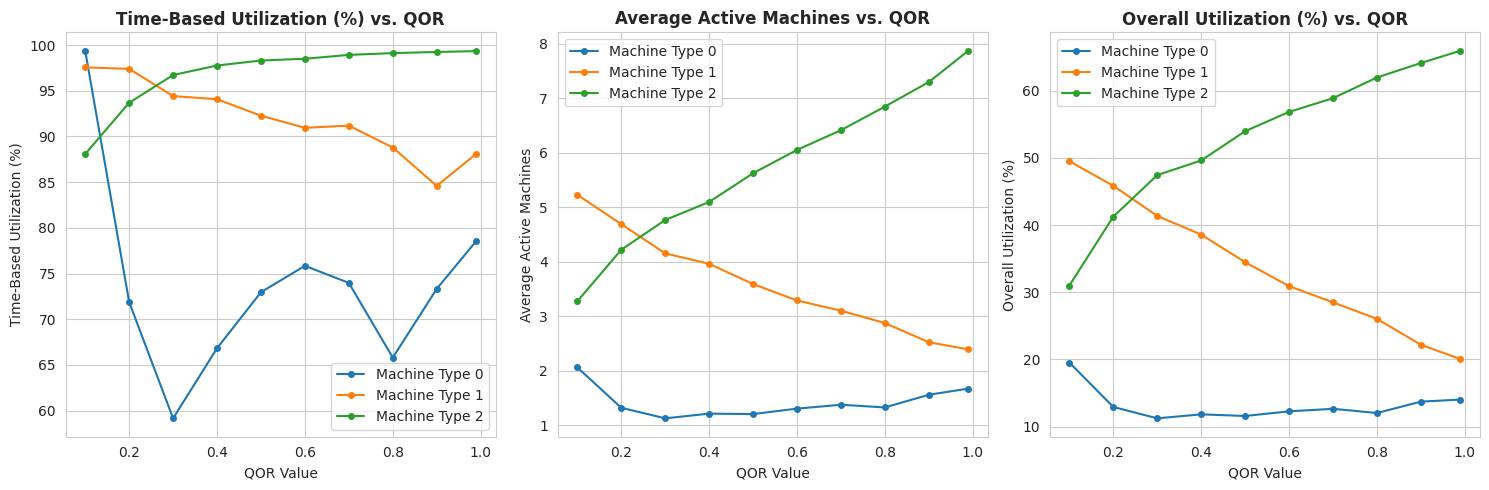

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")  # Professional, journal-like
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # 3-panel for single-row subplots

metrics = ['time_based', 'avg_active', 'overall']
metric_labels = ['Time-Based Utilization (%)', 'Average Active Machines', 'Overall Utilization (%)']
qor_keys = sorted(results.keys())

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    for typ in machine_types:
        data = [results[qor][metric][typ] for qor in qor_keys]
        axes[i].plot(qor_keys, data, marker='o', markersize=4, label=f'Machine Type {typ}')
    axes[i].set_title(f'{label} vs. QOR', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('QOR Value')
    axes[i].set_ylabel(label)
    axes[i].legend(loc='best')
    axes[i].tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
plt.savefig('utilization_trends.pdf', format='pdf', dpi=300, bbox_inches='tight')  # Export to vector
plt.show()

Saved stacked_bar_utilization.pdf


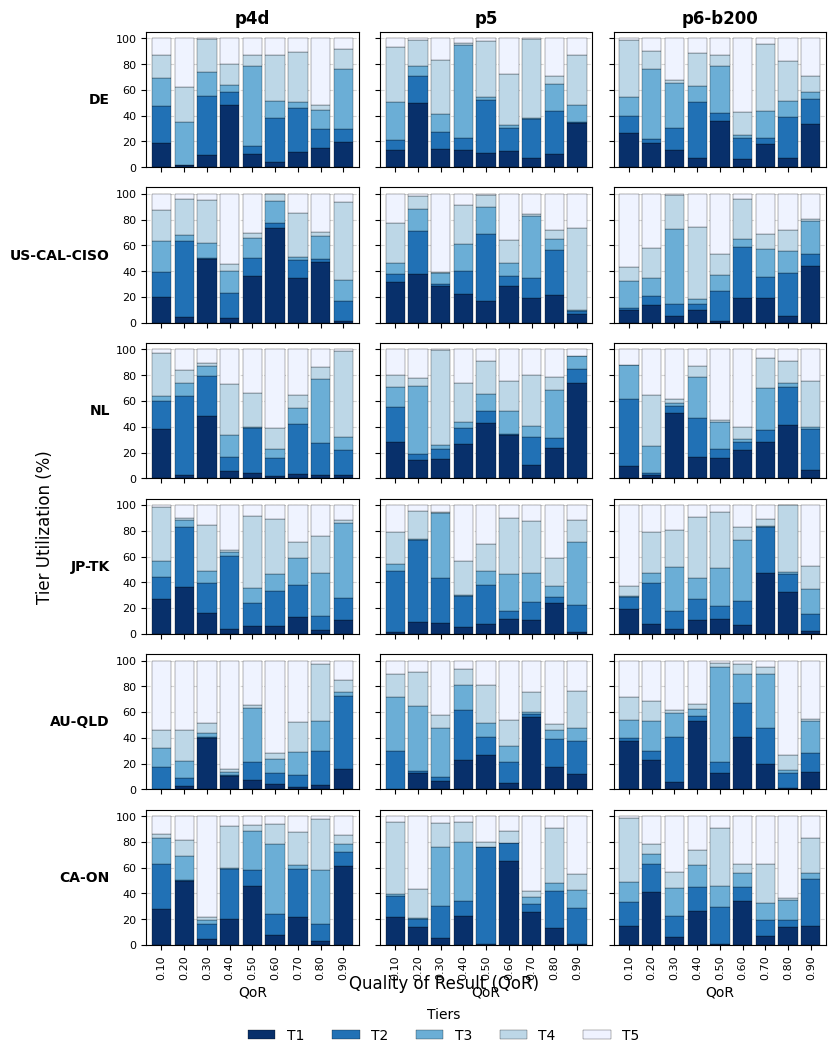

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ast
import os
import numpy as np


# ---------------------------------------------------------
# 1. CONFIGURATION
# ---------------------------------------------------------
base_path = "/home/chad/Desktop/multi-tier-llm-routing-v2/results/" 
output_filename = "heatmap_utilization_from_csv.pdf"

# Mappings based on your description
regions = ['DE', 'US-CAL-CISO', 'NL', 'JP-TK', 'AU-QLD', 'CA-ON']
qor_values = ['0.10', '0.20', '0.30', '0.40', '0.50', '0.60', '0.70', '0.80', '0.90']


machine_map = {'0': 'p4d', '1': 'p5', '2': 'p6-b200'} 
tier_map = {'tier_0': 'T1', 'tier_1': 'T2', 'tier_2': 'T3', 'tier_3': 'T4', 'tier_4': 'T5'}
tier_cols = ['T1', 'T2', 'T3', 'T4', 'T5'] # Order matters for stacking!

data_list = []

# ... (Assume Data Loading Loop is here, same as previous code block) ...
# For testing, I will generate dummy data structure matching your CSV result
# REPLACE THIS BLOCK WITH THE ACTUAL FILE READING LOOP FROM PREVIOUS ANSWER
np.random.seed(0)
for r in regions:
    for q in qor_values:
        for m_code, m_name in machine_map.items():
            # Mock percentages
            vals = np.random.dirichlet(np.ones(5), size=1)[0] * 100
            entry = {'Region': r, 'QoR': q, 'Machine': m_name}
            for i, t in enumerate(tier_cols):
                entry[t] = vals[i]
            data_list.append(entry)
# ---------------------------------------------------------

df_final = pd.DataFrame(data_list)

# ---------------------------------------------------------
# 2. CONFIGURING THE STACKED BAR PLOT
# ---------------------------------------------------------
machines_to_plot = ['p4d', 'p5', 'p6-b200']
n_regions = len(regions)
n_machines = len(machines_to_plot)

# Size: Fits a full IEEE page vertically
fig, axes = plt.subplots(n_regions, n_machines, figsize=(8.5, 11), sharex=True, sharey=True)

# Define Colors for Tiers (High contrast for T1, fading to T5)
# T1 = Dark Blue, T5 = Light Blue
colors = ['#08306b', '#2171b5', '#6baed6', '#bdd7e7', '#eff3ff'] 

# Iterate Grid
for i, region in enumerate(regions):
    for j, machine in enumerate(machines_to_plot):
        ax = axes[i, j]
        
        # Filter Data
        subset = df_final[(df_final['Region'] == region) & 
                          (df_final['Machine'] == machine)]
        
        if subset.empty:
            ax.axis('off')
            continue

        # Pivot: Index=QoR, Columns=Tiers (T1, T2...), Values=Utilization
        df_plot = subset.pivot(index='QoR', columns=tier_cols[0], values=tier_cols[0]) # Dummy init
        
        # Reconstruct correct pivot for stacking
        df_plot = subset.set_index('QoR')[tier_cols]
        
        # PLOT: Stacked Bar
        # width=0.08 ensures bars don't touch (since QoR steps are 0.1)
        df_plot.plot(kind='bar', stacked=True, ax=ax, color=colors, 
                     width=0.85, legend=False, edgecolor='k', linewidth=0.2)

        # Clean up Axes
        if j == 0:
            ax.set_ylabel(region, fontweight='bold', fontsize=10, rotation=0, ha='right', va='center')
        else:
            ax.set_ylabel('')

        if i == 0:
            ax.set_title(machine, fontweight='bold', fontsize=12)
        
        # X-Ticks cleanup
        ax.tick_params(axis='x', rotation=90, labelsize=8)
        ax.tick_params(axis='y', labelsize=8)
        
        # Add Grid behind bars
        ax.set_axisbelow(True)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# 3. GLOBAL LEGEND & LABELS
# ---------------------------------------------------------
# Create a single legend at the top or bottom
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=5, 
           bbox_to_anchor=(0.5, 0.02), frameon=False, title="Tiers")

fig.text(0.02, 0.5, 'Tier Utilization (%)', va='center', rotation='vertical', fontsize=12)
fig.text(0.5, 0.08, 'Quality of Result (QoR)', ha='center', fontsize=12)

# Layout adjustment
plt.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.12, wspace=0.1, hspace=0.15)

#plt.savefig("stacked_bar_utilization.pdf", dpi=300, bbox_inches='tight')
print("Saved stacked_bar_utilization.pdf")
plt.show()